# 05 -- Model Comparison (leakage-free)

* **GroupKFold by run_id** -- windows of one run never split across train/test.
* Feature selection (mutual-info top-K) is a **pipeline step**, fitted per
  fold on the training split only (no selection leakage).
* Scaling only where needed: trees get none, SVM gets StandardScaler.
* Two leagues, never cross-ranked: feature league (RF / ExtraTrees / XGBoost /
  SVM) vs sequence league (LSTM on raw windows, only if TensorFlow is
  installed).
* Selection metric = macro-F1; balanced accuracy + per-class recall also
  reported. Plain accuracy is shown but not used to choose the winner.

Every model's full metrics are printed individually below, then compared
side by side in one table + bar chart.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import pdm_common as P


import json, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score
warnings.filterwarnings("ignore")

feat = pd.read_parquet(P.ART_DIR / "features.parquet")
feat_cols = [c for c in feat.columns if c not in ("run_id", "label", "t_start")]
X = feat[feat_cols].to_numpy()
le = LabelEncoder(); y = le.fit_transform(feat["label"])
groups = feat["run_id"].to_numpy()
K = min(20, len(feat_cols))
n_groups = feat["run_id"].nunique()
cv = GroupKFold(n_splits=min(3, n_groups))
print(f"{X.shape[0]} windows, {len(feat_cols)} features, {n_groups} runs, "
      f"GroupKFold={cv.get_n_splits()} folds, top-K={K}")

for tr, te in cv.split(X, y, groups):
    assert not (set(groups[tr]) & set(groups[te])), "run leak across fold!"
print("Leakage check passed: train/test runs are disjoint in every fold.")

267 windows, 51 features, 13 runs, GroupKFold=3 folds, top-K=20
Leakage check passed: train/test runs are disjoint in every fold.


## Feature-league models -- each shown individually

In [2]:
feature_models = P.build_feature_models(K)
rows = []
for name, model in feature_models.items():
    pred = cross_val_predict(model, X, y, cv=cv, groups=groups)
    row = dict(league="feature", model=name,
               macro_f1=f1_score(y, pred, average="macro"),
               balanced_acc=balanced_accuracy_score(y, pred),
               accuracy=accuracy_score(y, pred),
               min_class_recall=recall_score(y, pred, average=None).min())
    rows.append(row)
    print(f"\n=== {name} ===")
    display(pd.DataFrame([row]).round(3))
    per_class = pd.DataFrame({"recall": recall_score(y, pred, average=None, zero_division=0)},
                             index=le.classes_)
    display(per_class.round(3))


=== RandomForest ===


,league,model,macro_f1,balanced_acc,accuracy,min_class_recall
0,feature,RandomForest,0.493,0.514,0.689,0.0


,recall
FlexibleShaft,0.000
GeneratorFault,0.707
Healthy,0.000
Leakage,1.000
PumpDisplacement,0.865



=== ExtraTrees ===


,league,model,macro_f1,balanced_acc,accuracy,min_class_recall
0,feature,ExtraTrees,0.494,0.508,0.685,0.0


...

,league,model,macro_f1,balanced_acc,accuracy,min_class_recall
0,feature,SVM_RBF,0.457,0.505,0.678,0.0


,recall
FlexibleShaft,0.000
GeneratorFault,0.585
Healthy,0.000
Leakage,1.000
PumpDisplacement,0.938



=== XGBoost ===


,league,model,macro_f1,balanced_acc,accuracy,min_class_recall
0,feature,XGBoost,0.465,0.512,0.685,0.0


,recall
FlexibleShaft,0.000
GeneratorFault,0.695
Healthy,0.000
Leakage,1.000
PumpDisplacement,0.865


## Sequence league -- LSTM (only runs if TensorFlow is installed)

In [ ]:
try:
    import torch
    import torch.nn as nn
    d = np.load(P.ART_DIR / "windows.npz", allow_pickle=True)
    Xs, gseq = d["X"].astype("float32"), d["run_id"]
    yseq = le.transform(d["label"])
    preds = np.zeros_like(yseq)
    torch.manual_seed(0)
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    n_cls = len(le.classes_)
    for tr, te in cv.split(Xs, yseq, gseq):
        mu, sd = Xs[tr].mean((0, 1)), Xs[tr].std((0, 1)) + 1e-9
        Xtr = torch.tensor((Xs[tr] - mu) / sd, device=dev)
        Xte = torch.tensor((Xs[te] - mu) / sd, device=dev)
        ytr = torch.tensor(yseq[tr], dtype=torch.long, device=dev)
        lstm = nn.LSTM(Xs.shape[2], 32, batch_first=True).to(dev)
        head = nn.Linear(32, n_cls).to(dev)
        opt = torch.optim.Adam([*lstm.parameters(), *head.parameters()])
        lossf = nn.CrossEntropyLoss()
        for _ in range(15):
            for b in torch.randperm(len(Xtr), device=dev).split(32):
                opt.zero_grad()
                loss = lossf(head(lstm(Xtr[b])[0][:, -1]), ytr[b])
                loss.backward(); opt.step()
        lstm.eval(); head.eval()
        with torch.no_grad():
            preds[te] = head(lstm(Xte)[0][:, -1]).argmax(1).cpu().numpy()
    row = dict(league="sequence", model="LSTM",
               macro_f1=f1_score(yseq, preds, average="macro"),
               balanced_acc=balanced_accuracy_score(yseq, preds),
               accuracy=accuracy_score(yseq, preds),
               min_class_recall=recall_score(yseq, preds, average=None).min())
    rows.append(row)
    print("=== LSTM (sequence league, PyTorch) ===")
    display(pd.DataFrame([row]).round(3))
except Exception as e:
    print(f"LSTM skipped (sequence league): {type(e).__name__}: {e}")
    print("-> deployment model is chosen from the feature league.")

## Final comparison -- all models together

,league,model,macro_f1,balanced_acc,accuracy,min_class_recall
1,feature,ExtraTrees,0.494,0.508,0.685,0.0
0,feature,RandomForest,0.493,0.514,0.689,0.0
3,feature,XGBoost,0.465,0.512,0.685,0.0
2,feature,SVM_RBF,0.457,0.505,0.678,0.0


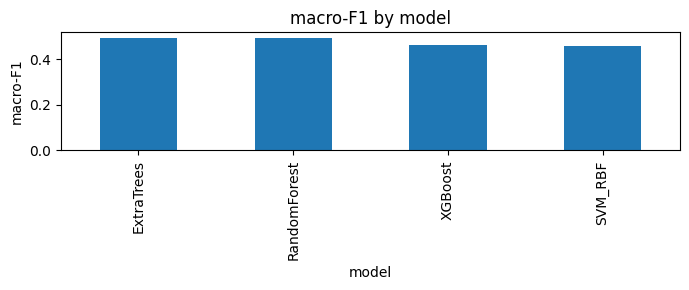

Selected deployment model (feature league, max macro-F1): ExtraTrees


In [4]:
comp = pd.DataFrame(rows).sort_values(["league", "macro_f1"], ascending=[True, False])
comp.to_csv(P.ART_DIR / "model_comparison.csv", index=False)

best = comp[comp.league == "feature"].sort_values("macro_f1").iloc[-1]["model"]
(P.ART_DIR / "best_model.json").write_text(json.dumps({"best": best}))

display(comp.round(3))
ax = comp.set_index("model")["macro_f1"].plot.bar(figsize=(7, 3), title="macro-F1 by model")
ax.set_ylabel("macro-F1"); plt.tight_layout(); plt.show()
print(f"Selected deployment model (feature league, max macro-F1): {best}")

## Feature-group ablation (validates the invariant-vs-deviation design claim)

In [5]:
_dev = ("_dmean", "_dstd", "_drms")
_groups = {"all": feat_cols,
          "invariant": [c for c in feat_cols if not c.endswith(_dev)],
          "deviation": [c for c in feat_cols if c.endswith(_dev)]}
_gi = list(le.classes_).index("GeneratorFault") if "GeneratorFault" in le.classes_ else None

abl = []
for gname, cols in _groups.items():
    if not cols:
        continue
    Xg = feat[cols].to_numpy()
    mdl = P.build_feature_models(min(K, len(cols)))[best]
    pg = cross_val_predict(mdl, Xg, y, cv=cv, groups=groups)
    rec = recall_score(y, pg, average=None, zero_division=0)
    abl.append(dict(group=gname, n_feats=len(cols),
                    macro_f1=f1_score(y, pg, average="macro"),
                    balanced_acc=balanced_accuracy_score(y, pg),
                    gen_recall=float(rec[_gi]) if _gi is not None else np.nan))
abl_df = pd.DataFrame(abl)
abl_df.to_csv(P.ART_DIR / "feature_group_ablation.csv", index=False)
display(abl_df.round(3))
print("Claim holds iff 'invariant' keeps GeneratorFault recall close to 'all'.")

,group,n_feats,macro_f1,balanced_acc,gen_recall
0,all,51,0.494,0.508,0.573
1,invariant,39,0.477,0.491,0.537
2,deviation,12,0.435,0.444,0.500


Claim holds iff 'invariant' keeps GeneratorFault recall close to 'all'.
